# Proyecto de Visión Computacional  
## Clasificación de defectos en superficies metálicas

### Problema
Dada una imagen de una superficie metálica, se quiere identificar automáticamente a qué clase de defecto pertenece.

### Estrategia
Se va a comparar cuatro modelos:

1. **CNN básica** entrenada desde cero → sirve como **baseline**.
2. **ResNet-18** con transfer learning.
3. **EfficientNet-B0** con transfer learning.
4. **MobileNetV3-Small** con transfer learning.

**Datos:** `industrial_defect_dataset/train` y `val` (PNG 256×256, grayscale → RGB para ImageNet)  

### Métricas principales
- Accuracy
- F1 macro
- Precision y recall por clase
- Matriz de confusión
- Curvas de entrenamiento

## 1. Configuración e imports

In [1]:
from __future__ import annotations

import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from torchvision.models import (
    EfficientNet_B0_Weights,
    MobileNet_V3_Small_Weights,
    ResNet18_Weights,
)
from tqdm.auto import tqdm


In [2]:

# RUTAS

# Se usan rutas relativas para que el proyecto funcione en cualquier computadora después de hacer git clone.
ROOT = Path(".").resolve()

DATA_DIR = ROOT / "industrial_defect_dataset"
OUTPUT_DIR = ROOT / "outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIGURES_DIR = ROOT / "docs" / "figures"

OUTPUT_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# HIPERPARÁMETROS

# Semilla:
# permite repetir el experimento bajo condiciones similares.
SEED = 42

# Tamaño de entrada:
# el dataset trabaja con imágenes de 256x256, por eso se mantiene esta resolución.
IMG_SIZE = 256

# Batch size:
# se procesan 32 imágenes por iteración. Es un valor intermedio entre estabilidad y consumo de memoria.
BATCH_SIZE = 32

# Máximo de épocas:
# el modelo puede recorrer el dataset hasta 20 veces. Early stopping puede detenerlo antes.
NUM_EPOCHS = 20

# Learning rate:
# controla qué tan grandes son los cambios en los pesos. 3e-4 es un valor pequeño y común para fine-tuning.
LR = 3e-4

# Weight decay:
# regularización que ayuda a reducir sobreajuste.
WEIGHT_DECAY = 1e-4

# Early stopping:
# si F1 macro no mejora durante 5 épocas seguidas, se detiene el entrenamiento.
PATIENCE = 5

# En WSL podemos dejar 2 workers.
# Si hubiera problemas con el DataLoader, cambiar temporalmente a 0.
NUM_WORKERS = 0


# Orden de comparación:
# primero la CNN básica y luego los modelos preentrenados.
MODELS_TO_TRAIN = [
    "cnn_baseline",
    "resnet18",
    "efficientnet_b0",
    "mobilenet_v3_small",
]

### Selección del dispositivo de cómputo

Aquí se configura dónde se ejecutará el entrenamiento. La variable `DEVICE_MODE` acepta:

- `"auto"`: detecta automáticamente lo disponible (prioriza CUDA, luego MPS, luego CPU).
- `"cuda"`: fuerza el uso de una **GPU NVIDIA**.
- `"mps"`: fuerza el uso de la **GPU de Apple Silicon (Mac)**.
- `"cpu"`: fuerza el uso del **procesador**.

Si se fuerza un modo que no está disponible en el equipo, la celda lanza un error con un mensaje claro.

In [3]:
# DISPOSITIVO

# Modo de ejecución:
#   "auto" -> detecta automáticamente (CUDA > MPS > CPU)
#   "cuda" -> fuerza GPU NVIDIA
#   "mps"  -> fuerza GPU de Apple Silicon (Mac)
#   "cpu"  -> fuerza CPU
DEVICE_MODE = "cuda"


def select_device(mode: str = "auto") -> torch.device:
    mode = mode.lower()

    if mode == "auto":
        if torch.cuda.is_available():
            return torch.device("cuda:0")
        if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
            return torch.device("mps")
        return torch.device("cpu")

    if mode == "cuda":
        if not torch.cuda.is_available():
            raise RuntimeError("Se forzó 'cuda' pero no hay GPU NVIDIA disponible.")
        return torch.device("cuda:0")

    if mode == "mps":
        if not (getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()):
            raise RuntimeError("Se forzó 'mps' pero MPS no está disponible en este equipo.")
        return torch.device("mps")

    if mode == "cpu":
        return torch.device("cpu")

    raise ValueError(f"Modo desconocido: {mode!r}. Usa 'auto', 'cuda', 'mps' o 'cpu'.")


DEVICE = select_device(DEVICE_MODE)
USE_CUDA = DEVICE.type == "cuda"

print(f"PyTorch: {torch.__version__}")
print(f"Modo configurado: {DEVICE_MODE}")
print(f"Dispositivo seleccionado: {DEVICE}")

if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif DEVICE.type == "mps":
    print("GPU Apple Silicon (MPS) activa.")
else:
    print("El entrenamiento se realizará en CPU.")

PyTorch: 2.13.0+cu130
Modo configurado: cuda
Dispositivo seleccionado: cuda:0
GPU: NVIDIA GeForce RTX 5060 Ti


In [4]:
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Estas opciones ayudan a mejorar la reproducibilidad en CUDA.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

print(f"Semilla fijada en: {SEED}")


Semilla fijada en: 42


## 2. Dataset y DataLoaders

Las imágenes son grayscale (`L`). Se convierten a RGB (3 canales) para usar pesos ImageNet.

### División del dataset: train / validation / test

El dataset se divide en tres particiones **estratificadas** (misma proporción por clase):

| Partición | Imágenes | Por clase | Uso |
|---|---|---|---|
| train | 12 000 | 2 400 | Entrenamiento (con data augmentation) |
| validation | 1 500 | 300 | Early stopping y selección del mejor checkpoint |
| test | 1 500 | 300 | **Evaluación final, una sola vez, al terminar** |

La partición de test se generó moviendo la mitad de las imágenes de `val/` a `test/`,
seleccionadas al azar con la semilla fija `SEED = 42`, por lo que la división es
reproducible y no hay solape entre particiones (sin fuga de datos).

**Importante:** el conjunto de test no participa en el entrenamiento ni en la selección
de hiperparámetros; solo se usa en la sección 8.1 para reportar las métricas finales.


In [ ]:
# Valores estándar de normalización utilizados por los modelos de ImageNet.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Transformaciones para entrenamiento.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # El dataset es grayscale, pero los modelos preentrenados
    # esperan una entrada RGB de 3 canales.
    transforms.Grayscale(num_output_channels=3),

    # Data augmentation.
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),

    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
# Transformaciones para validación.

val_transform = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

train_ds = datasets.ImageFolder(DATA_DIR / "train", transform=train_transform)
val_ds = datasets.ImageFolder(DATA_DIR / "val", transform=val_transform)

# Conjunto de test: usa las mismas transformaciones de validación (sin augmentation).
test_dir = DATA_DIR / "test"
assert test_dir.exists(), (
    "No existe la carpeta test/. Debe generarse moviendo la mitad de las "
    "imágenes de val/ (300 por clase, semilla 42)."
)
test_ds = datasets.ImageFolder(test_dir, transform=val_transform)

# Se verifica que train y val tengan exactamente las mismas clases.

assert train_ds.classes == val_ds.classes == test_ds.classes, (
    "Las clases de train, val y test no coinciden."
)

CLASS_NAMES = train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)

print("Clases encontradas:", CLASS_NAMES)
print(f"Cantidad de clases: {NUM_CLASSES}")
print(f"Imágenes de entrenamiento: {len(train_ds)}")
print(f"Imágenes de validación: {len(val_ds)}")
print(f"Imágenes de test: {len(test_ds)}")



Clases encontradas: ['crack', 'hole', 'normal', 'rust', 'scratch']
Cantidad de clases: 5
Imágenes de entrenamiento: 12000
Imágenes de validación: 1500
Imágenes de test: 1500


In [ ]:
# Distribución de clases
train_counts = np.bincount(
    train_ds.targets,
    minlength=NUM_CLASSES
)

val_counts = np.bincount(
    val_ds.targets,
    minlength=NUM_CLASSES
)

test_counts = np.bincount(
    test_ds.targets,
    minlength=NUM_CLASSES
)

class_distribution = pd.DataFrame({
    "clase": CLASS_NAMES,
    "train": train_counts,
    "val": val_counts,
    "test": test_counts,
    "total": train_counts + val_counts + test_counts,
})

class_distribution

,clase,train,val,test,total
0,crack,2400,300,300,3000
1,hole,2400,300,300,3000
2,normal,2400,300,300,3000
3,rust,2400,300,300,3000
4,scratch,2400,300,300,3000


### DataLoaders

El `DataLoader` entrega las imágenes al modelo por lotes.

- En **train** se usa `shuffle=True` para variar el orden de las imágenes.
- En **validation** se usa `shuffle=False` porque no se necesita aleatoriedad al evaluar.
- En **test** también se usa `shuffle=False`, por la misma razón.

In [ ]:
generator = torch.Generator()
generator.manual_seed(SEED)

loader_kwargs = {
    "num_workers": NUM_WORKERS,
    "pin_memory": USE_CUDA,
}

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator,
    **loader_kwargs,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

images_batch, labels_batch = next(iter(train_loader))

print("Forma del batch:", images_batch.shape)
print("Ejemplo de etiquetas:", labels_batch[:10])


Forma del batch: torch.Size([32, 3, 256, 256])
Ejemplo de etiquetas: tensor([4, 1, 2, 0, 3, 0, 0, 4, 4, 1])


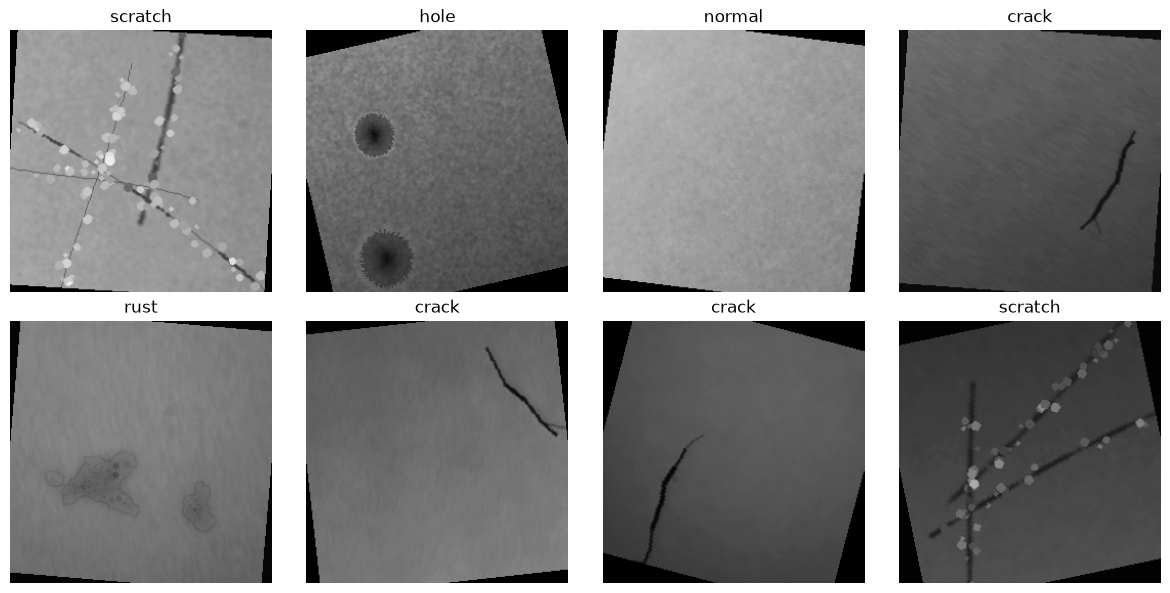

In [ ]:
#  Visualización rápida de imágenes
def desnormalizar(img):
    img = img.permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)


fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, img, label in zip(
    axes.ravel(),
    images_batch[:8],
    labels_batch[:8]
):
    ax.imshow(desnormalizar(img))
    ax.set_title(CLASS_NAMES[int(label)])
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Modelos 

### 3.1 CNN básica — baseline

La CNN se entrena **desde cero**.

La arquitectura usa:

- convoluciones para extraer patrones,
- ReLU como función de activación,
- MaxPooling para reducir dimensiones,
- Batch Normalization para estabilizar el entrenamiento,
- Dropout para regularización,
- una capa final para clasificar las 5 categorías.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(

            # Bloque 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 4
            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Reduce cada mapa de características a un solo valor.
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),

            # Dropout ayuda a reducir sobreajuste.
            nn.Dropout(0.30),

            # Salida final: una neurona por clase.
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


### 3.2 Modelos preentrenados

Se usa transfer learning con tres arquitecturas conocidas:

- **ResNet-18:** modelo relativamente compacto y muy utilizado; sus conexiones residuales facilitan el entrenamiento.
- **EfficientNet-B0:** busca buen equilibrio entre precisión y cantidad de parámetros.
- **MobileNetV3-Small:** modelo ligero, interesante para una futura aplicación en hardware limitado.



In [ ]:
def build_model(name, num_classes=NUM_CLASSES):

    name = name.lower()

    # CNN básica entrenada desde cero

    if name == "cnn_baseline":
        model = SimpleCNN(num_classes)

    # ResNet-18 preentrenada en ImageNet

    elif name == "resnet18":
        model = models.resnet18(
            weights=ResNet18_Weights.DEFAULT
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            num_classes
        )

    # EfficientNet-B0 preentrenada en ImageNet

    elif name == "efficientnet_b0":
        model = models.efficientnet_b0(
            weights=EfficientNet_B0_Weights.DEFAULT
        )

        in_features = model.classifier[1].in_features

        model.classifier[1] = nn.Linear(
            in_features,
            num_classes
        )

    # MobileNetV3-Small preentrenada en ImageNet

    elif name == "mobilenet_v3_small":
        model = models.mobilenet_v3_small(
            weights=MobileNet_V3_Small_Weights.DEFAULT
        )

        in_features = model.classifier[3].in_features

        model.classifier[3] = nn.Linear(
            in_features,
            num_classes
        )

    else:
        raise ValueError(f"Modelo no reconocido: {name}")

    return model


In [ ]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


for model_name in MODELS_TO_TRAIN:

    model = build_model(model_name)

    print(
        f"{model_name:22s} "
        f"parámetros entrenables: {count_parameters(model):,}"
    )


cnn_baseline           parámetros entrenables: 390,661
resnet18               parámetros entrenables: 11,179,077


efficientnet_b0        parámetros entrenables: 4,013,953
mobilenet_v3_small     parámetros entrenables: 1,522,981



## 4. Función de pérdida y optimizador

### CrossEntropyLoss
Se usa porque el problema es de **clasificación multiclase**: cada imagen pertenece a una sola clase.

### AdamW
Se usa AdamW porque combina el comportamiento adaptativo de Adam con una forma adecuada de aplicar `weight_decay`.



## 5. Funciones de evaluación

Además de accuracy se calcula **F1 macro**.

F1 macro calcula el F1 de cada clase por separado y luego obtiene el promedio, dando la misma importancia a todas las clases.

In [ ]:
torch.no_grad()
def evaluate(model, loader):

    model.eval()

    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    all_predictions = []
    all_labels = []

    for inputs, targets in loader:

        inputs = inputs.to(DEVICE)
        targets = targets.to(DEVICE)

        outputs = model(inputs)

        loss = criterion(outputs, targets)

        total_loss += (
            loss.item() * inputs.size(0)
        )

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            targets.cpu().numpy()
        )

    y_true = np.array(all_labels)
    y_pred = np.array(all_predictions)

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "f1_macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "y_true": y_true,
        "y_pred": y_pred,
    }


## 6. Entrenamiento

Esta función realiza el entrenamiento de un modelo.

Se usa **early stopping tomando F1 macro como referencia**:

- si F1 mejora, se guarda el modelo;
- si no mejora durante varias épocas, se detiene el entrenamiento.

Esto evita seguir entrenando cuando ya no se observa una mejora útil.

In [ ]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in tqdm(
        loader,
        leave=False
    ):

        inputs = inputs.to(DEVICE)
        targets = targets.to(DEVICE)

        # Eliminar gradientes anteriores.
        optimizer.zero_grad()

        # Forward:
        # el modelo genera una predicción.
        outputs = model(inputs)

        # Calcular el error.
        loss = criterion(
            outputs,
            targets
        )

        # Backpropagation.
        loss.backward()

        # Actualizar los pesos.
        optimizer.step()

        running_loss += (
            loss.item() * inputs.size(0)
        )

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == targets
        ).sum().item()

        total += targets.size(0)

    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    epoch_accuracy = (
        correct / total
    )

    return epoch_loss, epoch_accuracy


In [ ]:
def train_model(model_name):

    # Reiniciar la semilla antes de cada modelo.
    set_seed()

    model = build_model(
        model_name
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
    }

    best_f1 = -1
    best_state = None
    epochs_without_improvement = 0

    checkpoint_path = (
        CHECKPOINT_DIR /
        f"{model_name}_best.pt"
    )

    print(
        f"\nEntrenando {model_name} "
        f"en {DEVICE}"
    )

    start_time = time.time()

    for epoch in range(
        1,
        NUM_EPOCHS + 1
    ):

        train_loss, train_acc = (
            train_one_epoch(
                model,
                train_loader,
                optimizer,
                criterion
            )
        )

        val_metrics = evaluate(
            model,
            val_loader
        )

        history["epoch"].append(epoch)
        history["train_loss"].append(
            train_loss
        )
        history["train_acc"].append(
            train_acc
        )
        history["val_loss"].append(
            val_metrics["loss"]
        )
        history["val_acc"].append(
            val_metrics["accuracy"]
        )
        history["val_f1"].append(
            val_metrics["f1_macro"]
        )

        print(
            f"Época {epoch:02d}/{NUM_EPOCHS} | "
            f"train_acc={train_acc:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_f1={val_metrics['f1_macro']:.4f}"
        )

        # Guardar el mejor modelo según F1 macro.
        if val_metrics["f1_macro"] > best_f1:

            best_f1 = (
                val_metrics["f1_macro"]
            )

            best_state = {
                key: value.detach().cpu().clone()
                for key, value
                in model.state_dict().items()
            }

            epochs_without_improvement = 0

            torch.save(
                {
                    "model_name": model_name,
                    "state_dict": best_state,
                    "class_names": CLASS_NAMES,
                    "img_size": IMG_SIZE,
                    "metrics": {
                        "accuracy":
                            val_metrics["accuracy"],
                        "f1_macro":
                            val_metrics["f1_macro"],
                        "f1_weighted":
                            val_metrics["f1_weighted"],
                    },
                },
                checkpoint_path
            )

        else:

            epochs_without_improvement += 1

            if (
                epochs_without_improvement
                >= PATIENCE
            ):

                print(
                    "Early stopping: "
                    "el F1 macro dejó de mejorar."
                )

                break

    training_time = (
        time.time() - start_time
    )

    # Recuperar el mejor estado.
    model.load_state_dict(
        best_state
    )

    final_metrics = evaluate(
        model,
        val_loader
    )

    return {
        "model": model_name,
        "params":
            count_parameters(model),
        "epochs_run":
            len(history["epoch"]),
        "seconds":
            training_time,
        "accuracy":
            final_metrics["accuracy"],
        "f1_macro":
            final_metrics["f1_macro"],
        "f1_weighted":
            final_metrics["f1_weighted"],
        "checkpoint":
            str(checkpoint_path),
        "history":
            history,
        "y_true":
            final_metrics["y_true"],
        "y_pred":
            final_metrics["y_pred"],
    }


## 7. Entrenamiento de los cuatro modelos

El entrenamiento puede tardar bastante en CPU.

In [ ]:
results = []

for model_name in MODELS_TO_TRAIN:

    result = train_model(
        model_name
    )

    results.append(result)



Entrenando cnn_baseline en cuda:0


  0%|          | 0/375 [00:00<?, ?it/s]

Época 01/20 | train_acc=0.7993 | val_acc=0.9407 | val_f1=0.9414


  0%|          | 0/375 [00:00<?, ?it/s]

Época 02/20 | train_acc=0.9519 | val_acc=0.9580 | val_f1=0.9591


...

Época 04/20 | train_acc=0.9998 | val_acc=0.9627 | val_f1=0.9623


  0%|          | 0/375 [00:00<?, ?it/s]

Época 05/20 | train_acc=0.9982 | val_acc=1.0000 | val_f1=1.0000


  0%|          | 0/375 [00:00<?, ?it/s]

Época 06/20 | train_acc=0.9998 | val_acc=1.0000 | val_f1=1.0000
Early stopping: el F1 macro dejó de mejorar.


## 8. Tabla comparativa de resultados

La tabla permite comparar:

- precisión global,
- F1 macro,
- F1 weighted,
- cantidad de parámetros,
- épocas ejecutadas,
- tiempo de entrenamiento.

**Nota:** estas métricas corresponden al conjunto de **validación** (el usado para early stopping). Las métricas finales reportables sobre el conjunto de **test** se calculan en la sección 8.1.



In [ ]:
summary = pd.DataFrame([
    {
        "model": r["model"],
        "accuracy": r["accuracy"],
        "f1_macro": r["f1_macro"],
        "f1_weighted": r["f1_weighted"],
        "params": r["params"],
        "epochs": r["epochs_run"],
        "minutes": r["seconds"] / 60,
        "checkpoint": r["checkpoint"],
    }
    for r in results
])

summary = summary.sort_values(
    "f1_macro",
    ascending=False
).reset_index(drop=True)

summary


,model,accuracy,f1_macro,f1_weighted,params,epochs,minutes,checkpoint
0,resnet18,1.000000,1.000000,1.000000,11179077,7,7.870352,G:\Maestria\Modulo 9\Proyecto Final\outputs\ch...
1,efficientnet_b0,1.000000,1.000000,1.000000,4013953,6,7.826473,G:\Maestria\Modulo 9\Proyecto Final\outputs\ch...
2,mobilenet_v3_small,1.000000,1.000000,1.000000,1522981,6,5.879083,G:\Maestria\Modulo 9\Proyecto Final\outputs\ch...
3,cnn_baseline,0.999333,0.999333,0.999333,390661,17,18.758693,G:\Maestria\Modulo 9\Proyecto Final\outputs\ch...


### 8.1 Evaluación final sobre el conjunto de test

La selección del mejor checkpoint se hizo con **validation** (early stopping por F1 macro).
Ahora cada modelo se evalúa **una sola vez** sobre **test**, que permaneció intocable
durante todo el proceso. Estas son las métricas que se reportan en el informe.


In [ ]:
# Evaluación final sobre el conjunto de TEST.
# Test no se usó ni para entrenar ni para early stopping:
# solo se evalúa aquí, una sola vez, con el mejor checkpoint de cada modelo.


def load_best_model(result):

    model_name = result["model"]

    checkpoint = torch.load(
        result["checkpoint"],
        map_location=DEVICE
    )

    model = build_model(
        model_name
    ).to(DEVICE)

    model.load_state_dict(
        checkpoint["state_dict"]
    )

    model.eval()

    return model


test_results = []

for r in results:

    model = load_best_model(r)

    metrics = evaluate(
        model,
        test_loader
    )

    test_results.append({
        "model": r["model"],
        "loss": metrics["loss"],
        "accuracy": metrics["accuracy"],
        "f1_macro": metrics["f1_macro"],
        "f1_weighted": metrics["f1_weighted"],
        "y_true": metrics["y_true"],
        "y_pred": metrics["y_pred"],
    })

    print(
        f"{r['model']:22s} "
        f"test_acc={metrics['accuracy']:.4f} | "
        f"test_f1_macro={metrics['f1_macro']:.4f}"
    )

test_summary = pd.DataFrame([
    {
        "model": t["model"],
        "accuracy": t["accuracy"],
        "f1_macro": t["f1_macro"],
        "f1_weighted": t["f1_weighted"],
    }
    for t in test_results
])

test_summary = test_summary.sort_values(
    "f1_macro",
    ascending=False
).reset_index(drop=True)

test_summary.to_csv(
    OUTPUT_DIR / "test_summary.csv",
    index=False
)

print(f"\nTabla guardada en: {OUTPUT_DIR / 'test_summary.csv'}")

test_summary


cnn_baseline           test_acc=0.9987 | test_f1_macro=0.9987


resnet18               test_acc=1.0000 | test_f1_macro=1.0000


efficientnet_b0        test_acc=1.0000 | test_f1_macro=1.0000


mobilenet_v3_small     test_acc=1.0000 | test_f1_macro=1.0000

Tabla guardada en: G:\Maestria\Modulo 9\Proyecto Final\outputs\test_summary.csv


,model,accuracy,f1_macro,f1_weighted
0,resnet18,1.000000,1.000000,1.000000
1,efficientnet_b0,1.000000,1.000000,1.000000
2,mobilenet_v3_small,1.000000,1.000000,1.000000
3,cnn_baseline,0.998667,0.998668,0.998668


### Interpretación de los resultados en test

- **Sin brecha val → test:** las métricas de validación y test prácticamente coinciden
  (1.0000 en los tres preentrenados; 0.9993 → 0.9987 en la CNN baseline). Que test no sea
  peor que val indica buena generalización y descarta sobreajuste a la partición de validación.
- **El transfer learning domina:** los tres modelos preentrenados alcanzan el 100% en test.
  El conocimiento aprendido en ImageNet (bordes, texturas, gradientes) transfiere
  directamente a los defectos en superficies metálicas.
- **Costo/beneficio:** MobileNetV3-Small logra el mismo resultado que ResNet-18 con
  ~7× menos parámetros (1.5M vs 11.2M) y el menor tiempo de entrenamiento (5.8 min).
  Para un despliegue en hardware limitado es la mejor opción; ResNet-18 está
  sobredimensionada para este problema.
- **CNN baseline competitiva:** con solo 390K parámetros llega a 0.9987, pero tarda
  ~3× más en converger y comete los únicos 2 errores del experimento. Cumple su rol
  de baseline: demuestra que el problema es soluble desde cero, aunque el transfer
  learning es superior en precisión y en tiempo.


## 9. Curvas de entrenamiento

Aquí se muestra **train vs validation** para cada modelo.

### ¿Qué se busca?
- Si train mejora pero validation empeora, puede haber **sobreajuste**.
- Si ambas curvas son malas, puede haber **subajuste**.
- Si ambas mejoran y se mantienen próximas, es una señal positiva.

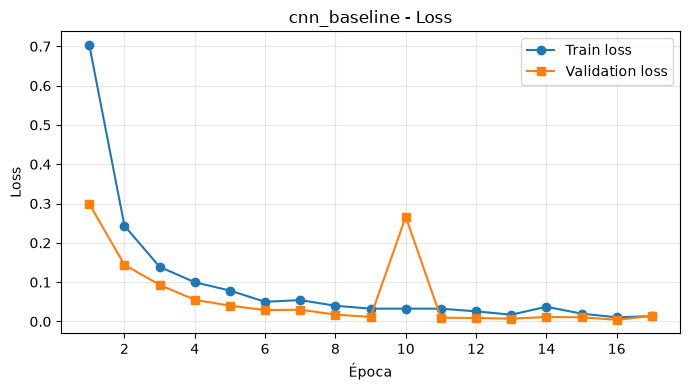

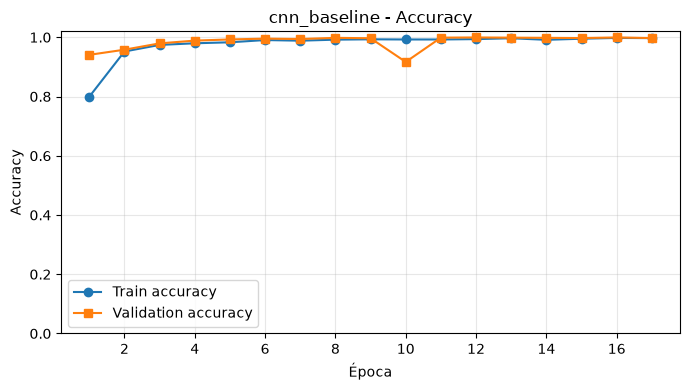

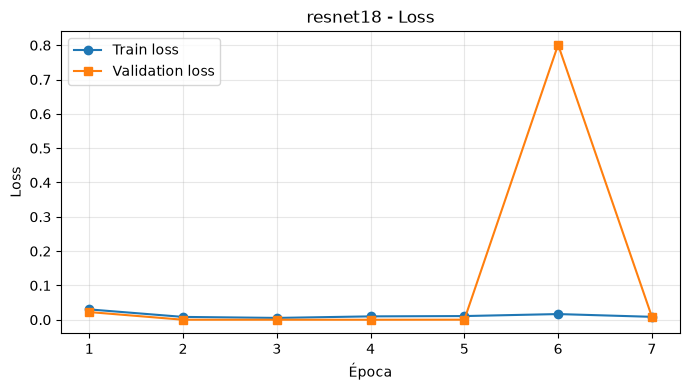

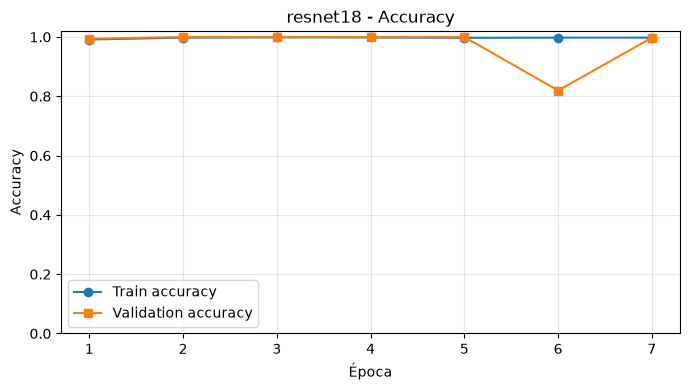

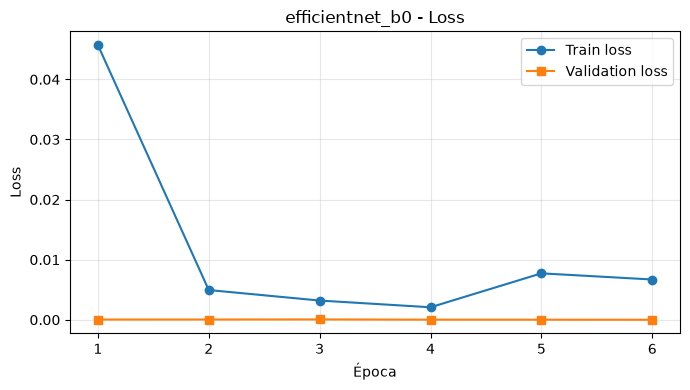

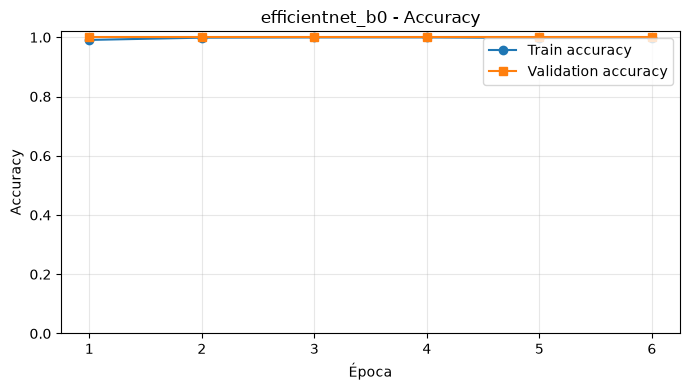

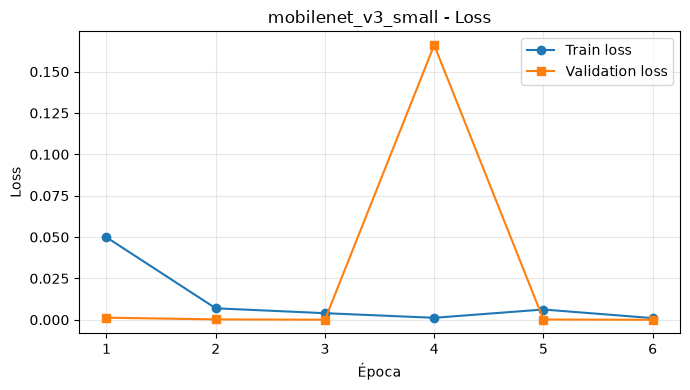

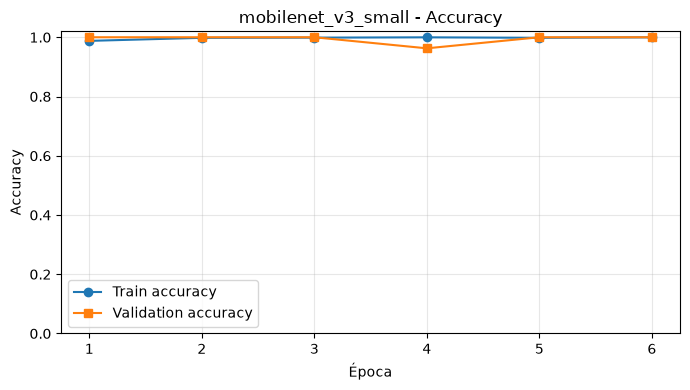

In [ ]:
for r in results:

    history = r["history"]

    # Curva de pérdida

    plt.figure(figsize=(7, 4))

    plt.plot(
        history["epoch"],
        history["train_loss"],
        marker="o",
        label="Train loss"
    )

    plt.plot(
        history["epoch"],
        history["val_loss"],
        marker="s",
        label="Validation loss"
    )

    plt.title(
        f"{r['model']} - Loss"
    )

    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR /
        f"{r['model']}_loss.png",
        dpi=150
    )

    plt.show()


    # Curva de accuracy
 
    plt.figure(figsize=(7, 4))

    plt.plot(
        history["epoch"],
        history["train_acc"],
        marker="o",
        label="Train accuracy"
    )

    plt.plot(
        history["epoch"],
        history["val_acc"],
        marker="s",
        label="Validation accuracy"
    )

    plt.title(
        f"{r['model']} - Accuracy"
    )

    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.02)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR /
        f"{r['model']}_accuracy.png",
        dpi=150
    )

    plt.show()


### Interpretación de las curvas

- **Preentrenados:** validation llega a 1.0 en 1-2 épocas. Es el comportamiento esperado
  con transfer learning: el modelo ya "sabe ver" y solo adapta su capa final al problema.
- **CNN baseline:** curva gradual de ~12 épocas hasta estabilizarse. Entrenar desde cero
  requiere aprender todos los filtros, de ahí la diferencia de velocidad de convergencia.
- **Picos de inestabilidad:** ResNet-18 (época 6, val 0.82), MobileNet (época 4, val 0.96)
  y la CNN (época 10, val 0.92) muestran caídas puntuales de validation con train estable.
  Son inestabilidades transitorias del optimizador (un lr de 3e-4 es agresivo para una red
  ya convergida). No afectan el resultado final porque se guarda el **mejor checkpoint**
  y el early stopping detiene el entrenamiento sin degradar ese mejor estado.
- **`val_acc > train_acc` en casi todas las épocas:** no es fuga de datos. El data
  augmentation (flips, rotación, jitter de brillo/contraste) hace que el entrenamiento sea
  más difícil que la validación, y en modo `eval()` el dropout se desactiva y BatchNorm usa
  estadísticas acumuladas, lo que estabiliza la evaluación.
- **Sin sobreajuste sostenido:** en ningún modelo train sube mientras val cae de forma
  persistente, que sería la señal clásica de overfitting.


## 10. Matrices de confusión

La matriz de confusión permite analizar **en qué clases se equivoca el modelo**.

Las matrices siguientes se calculan sobre el conjunto de **test**.

Esto es importante porque una sola cifra de accuracy no muestra qué defectos se están confundiendo entre sí.


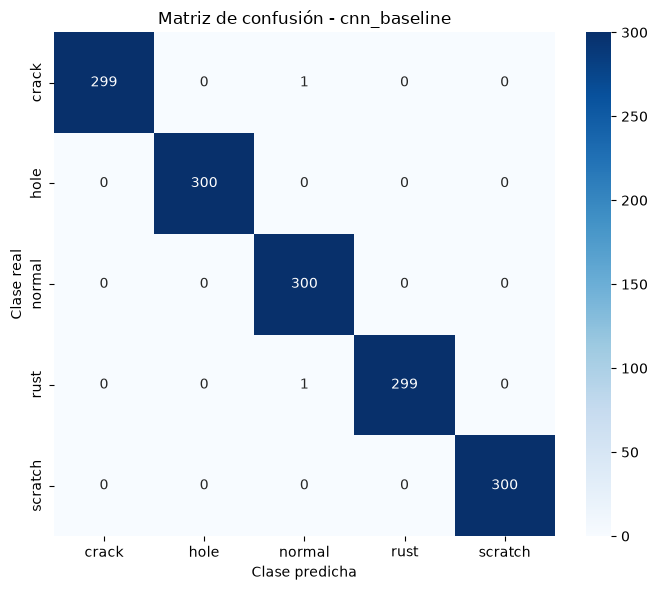

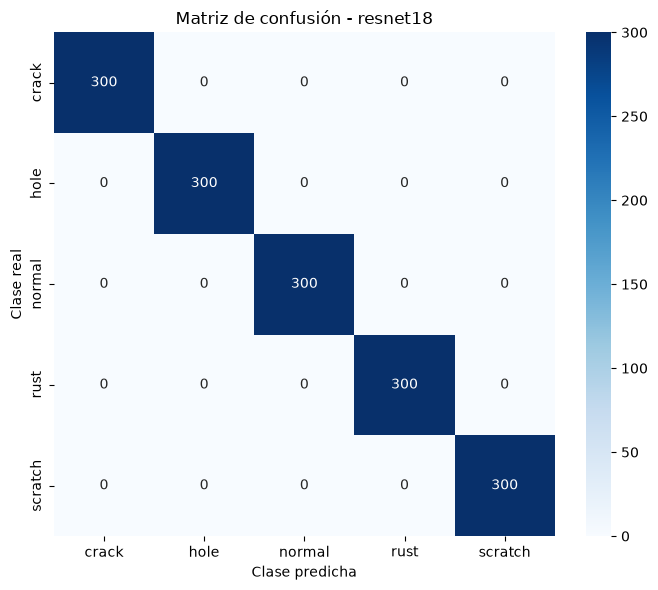

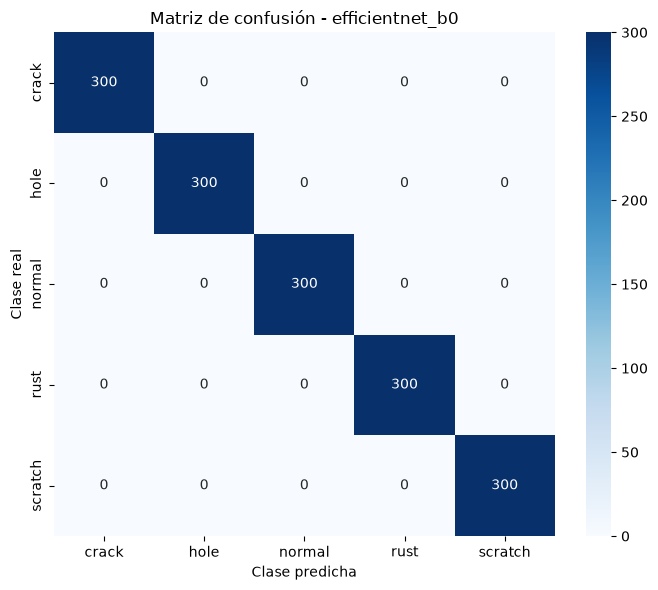

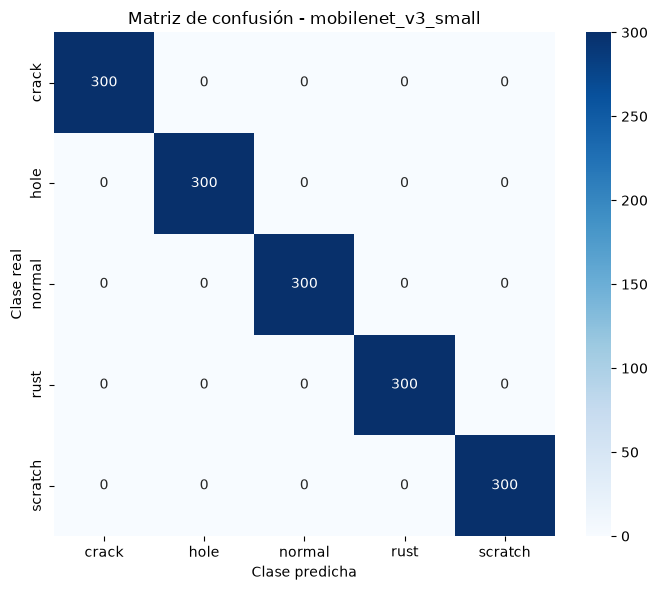

In [ ]:
for r in test_results:

    cm = confusion_matrix(
        r["y_true"],
        r["y_pred"]
    )

    plt.figure(
        figsize=(7, 6)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.title(
        f"Matriz de confusión - {r['model']}"
    )

    plt.xlabel("Clase predicha")
    plt.ylabel("Clase real")

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR /
        f"{r['model']}_confusion_matrix.png",
        dpi=150
    )

    plt.show()


### Interpretación de las matrices de confusión

- Los tres modelos preentrenados tienen matrices perfectas: diagonal pura con 300/300
  aciertos por clase y ceros fuera de la diagonal.
- La CNN baseline comete solo 2 errores de 1 500, ambos **hacia la clase `normal`**:
  un `crack` clasificado como `normal` y un `rust` clasificado como `normal`.
- **Hipótesis:** son falsos negativos de defecto — imágenes donde el defecto es pequeño
  o de bajo contraste y la textura de fondo domina la escena. Desde el punto de vista
  industrial es el error "menos grave" (no confunde tipos de defecto entre sí), aunque en
  producción un defecto clasificado como normal es justamente lo que se quiere evitar.
- Las clases `hole` y `scratch` tienen patrones geométricos muy distintivos (regiones
  oscuras circulares y líneas alargadas, respectivamente) y ningún modelo las confunde.


## 11. Precision, recall y F1 por clase

Estas métricas permiten comprobar si el modelo funciona bien para **todas las categorías** y no solo de forma global.


In [ ]:
for r in test_results:

    print(
        "\n" + "=" * 70
    )

    print(r["model"])

    print(
        classification_report(
            r["y_true"],
            r["y_pred"],
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0
        )
    )



cnn_baseline
              precision    recall  f1-score   support

       crack     1.0000    0.9967    0.9983       300
        hole     1.0000    1.0000    1.0000       300
      normal     0.9934    1.0000    0.9967       300
        rust     1.0000    0.9967    0.9983       300
     scratch     1.0000    1.0000    1.0000       300

    accuracy                         0.9987      1500
   macro avg     0.9987    0.9987    0.9987      1500
weighted avg     0.9987    0.9987    0.9987      1500


resnet18
              precision    recall  f1-score   support

       crack     1.0000    1.0000    1.0000       300
        hole     1.0000    1.0000    1.0000       300
      normal     1.0000    1.0000    1.0000       300
        rust     1.0000    1.0000    1.0000       300
     scratch     1.0000    1.0000    1.0000       300

    accuracy                         1.0000      1500
   macro avg     1.0000    1.0000    1.0000      1500
weighted avg     1.0000    1.0000    1.0000      1500

### Interpretación de precision y recall por clase

- En los preentrenados, precision y recall son 1.0 en las 5 clases: no existe una "clase
  difícil" para estos modelos en este dataset.
- En la CNN baseline, el recall de `crack` y `rust` es 0.9967 (un falso negativo por clase)
  y la precision de `normal` es 0.9934 (absorbe esos 2 errores). Todo lo demás es perfecto.
- **macro = weighted:** como el test está perfectamente balanceado (300 imágenes por
  clase), ambos promedios coinciden. Se reporta F1 **macro** como métrica principal porque
  es la métrica honesta cuando las clases podrían estar desbalanceadas en el caso real —
  da el mismo peso a cada defecto aunque tenga pocas imágenes.
- El `support` confirma que la partición de test es estratificada: exactamente 300
  imágenes por clase.


## 12. Análisis de predicciones correctas e incorrectas
La siguiente función muestra ejemplos del conjunto de **test** y separa:

- predicciones correctas,
- predicciones incorrectas.

In [ ]:
@torch.no_grad()
def collect_predictions(
    model,
    loader,
    max_items=200
):

    examples = []

    for images, labels in loader:

        images_device = images.to(DEVICE)

        outputs = model(
            images_device
        )

        predictions = outputs.argmax(
            dim=1
        ).cpu()

        for img, true_label, pred_label in zip(
            images,
            labels,
            predictions
        ):

            examples.append({
                "image": img,
                "true": int(true_label),
                "pred": int(pred_label),
                "correct":
                    int(true_label)
                    == int(pred_label),
            })

            if len(examples) >= max_items:
                return examples

    return examples


In [ ]:
# El mejor modelo se selecciona por F1 macro de VALIDACIÓN
# (usar test para seleccionar sería una fuga de datos).
best_result = results[
    int(
        np.argmax([
            r["f1_macro"]
            for r in results
        ])
    )
]

best_model = load_best_model(
    best_result
)

examples = collect_predictions(
    best_model,
    test_loader
)

correct_examples = [
    x for x in examples
    if x["correct"]
]

incorrect_examples = [
    x for x in examples
    if not x["correct"]
]

print(
    f"Mejor modelo: {best_result['model']}"
)

print(
    f"Correctas encontradas: {len(correct_examples)}"
)

print(
    f"Incorrectas encontradas: {len(incorrect_examples)}"
)


Mejor modelo: resnet18
Correctas encontradas: 200
Incorrectas encontradas: 0


In [ ]:
def show_examples(
    examples,
    title,
    n=10
):

    selected = examples[:n]

    if len(selected) == 0:
        print(
            f"No se encontraron ejemplos para: {title}"
        )
        return

    cols = 5
    rows = int(
        np.ceil(
            len(selected) / cols
        )
    )

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(15, 3 * rows)
    )

    axes = np.array(
        axes
    ).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, example in zip(
        axes,
        selected
    ):

        ax.imshow(
            desnormalizar(
                example["image"]
            )
        )

        true_name = CLASS_NAMES[
            example["true"]
        ]

        pred_name = CLASS_NAMES[
            example["pred"]
        ]

        ax.set_title(
            f"Real: {true_name}\n"
            f"Pred: {pred_name}",
            fontsize=9
        )

        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


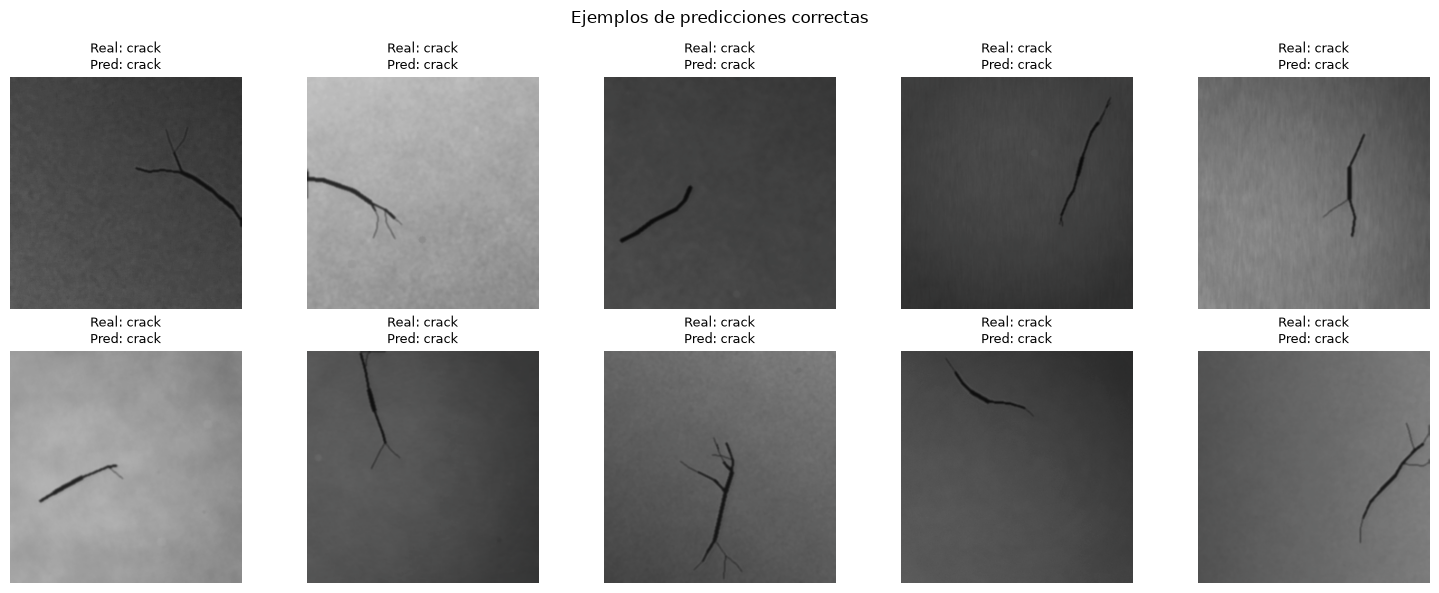

No se encontraron ejemplos para: Ejemplos de predicciones incorrectas


In [ ]:
show_examples(
    correct_examples,
    "Ejemplos de predicciones correctas",
    n=10
)

show_examples(
    incorrect_examples,
    "Ejemplos de predicciones incorrectas",
    n=10
)


### Preguntas que se deben hacer al analizar errores

- ¿El defecto es pequeño o poco visible?
- ¿La imagen tiene bajo contraste?
- ¿Dos clases tienen patrones visuales parecidos?
- ¿La imagen sintética contiene artefactos?
- ¿El modelo parece estar aprendiendo textura en lugar del defecto?
- ¿Existe alguna señal de fuga de datos?



### Sobre los ejemplos incorrectos

El mejor modelo (ResNet-18) **no comete ningún error** en el conjunto de test, por lo que
su grilla de incorrectas queda vacía. Es un resultado válido, pero para el análisis de
errores se muestran abajo los errores de la **CNN baseline** — los únicos 2 errores
existentes en todo el experimento.

**Implicación para el informe:** que 3 de 4 modelos alcancen el 100% indica que el dataset
sintético es demasiado fácil en comparación con el caso real (defectos grandes y de alto
contraste, iluminación uniforme, sin ruido de sensor). Estos resultados deben presentarse
como una **cota superior bajo condiciones ideales**, no como el desempeño esperado en
producción.


Errores de la CNN baseline en test: 2 de 1500
  real: crack    predicho como: normal
  real: rust     predicho como: normal


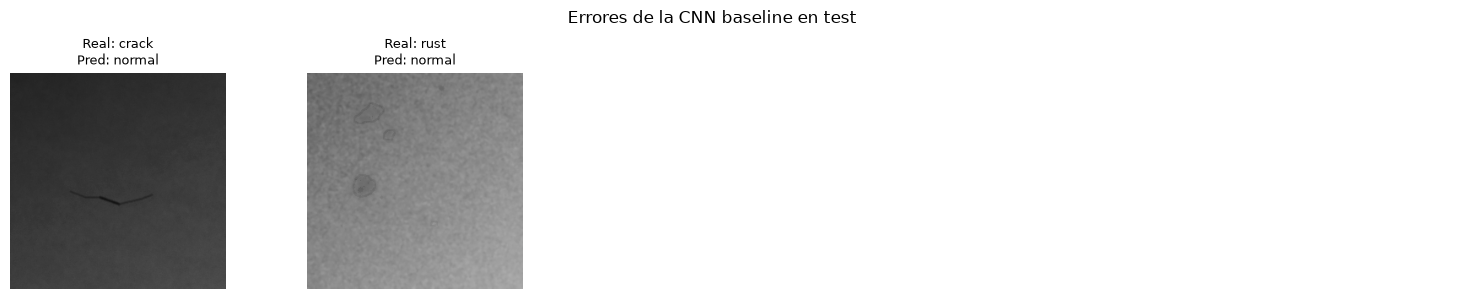

In [ ]:
# El mejor modelo (ResNet-18) no comete errores en test.
# Para el análisis de errores se usa la CNN baseline, la única
# que comete errores (2 de 1 500 imágenes).

baseline_result = next(
    r for r in results
    if r["model"] == "cnn_baseline"
)

baseline_model = load_best_model(
    baseline_result
)

# Se recorre TODO el conjunto de test (no solo 200 ejemplos)
# para no dejar ningún error fuera.
baseline_examples = collect_predictions(
    baseline_model,
    test_loader,
    max_items=len(test_ds)
)

baseline_incorrect = [
    x for x in baseline_examples
    if not x["correct"]
]

print(
    f"Errores de la CNN baseline en test: "
    f"{len(baseline_incorrect)} de {len(test_ds)}"
)

for x in baseline_incorrect:
    print(
        f"  real: {CLASS_NAMES[x['true']]:8s} "
        f"predicho como: {CLASS_NAMES[x['pred']]}"
    )

show_examples(
    baseline_incorrect,
    "Errores de la CNN baseline en test",
    n=10
)


## 13. Guardar resultados y configuración

Guardar la configuración es importante para la **reproducibilidad**.

Así se podrá saber exactamente qué hiperparámetros generaron las métricas reportadas.


In [ ]:
experiment = {
    "seed": SEED,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "num_epochs_max": NUM_EPOCHS,
    "learning_rate": LR,
    "weight_decay": WEIGHT_DECAY,
    "patience": PATIENCE,
    "device": str(DEVICE),
    "pytorch_version": torch.__version__,
    "classes": CLASS_NAMES,
    "train_size": len(train_ds),
    "val_size": len(val_ds),
    "test_size": len(test_ds),
    "models": summary.to_dict(
        orient="records"
    ),
    "test_models": test_summary.to_dict(
        orient="records"
    ),
}

config_path = (
    OUTPUT_DIR /
    "experiment_config.json"
)

with open(
    config_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        experiment,
        file,
        indent=2,
        ensure_ascii=False
    )

print(
    f"Configuración guardada en: {config_path}"
)


Configuración guardada en: G:\Maestria\Modulo 9\Proyecto Final\outputs\experiment_config.json


## 14. Conclusiones del experimento

**Resultado principal.** Los tres modelos con transfer learning (ResNet-18, EfficientNet-B0
y MobileNetV3-Small) clasifican los 5 tipos de defecto con accuracy y F1 = 1.0000 sobre un
test de 1 500 imágenes que no participó ni en el entrenamiento ni en la selección del
modelo. La CNN baseline entrenada desde cero alcanza 0.9987.

**Qué funcionó mejor de lo esperado.** La velocidad de convergencia del transfer learning:
EfficientNet y MobileNet llegan a validation perfecta desde la primera época, y el early
stopping con mejor checkpoint absorbió los picos de inestabilidad transitoria sin degradar
ningún modelo final.

**Qué no funcionó / limitaciones.** El dataset sintético no representa la dificultad del
caso real: defectos muy visibles, iluminación uniforme y sin ruido de sensor. Los scores
perfectos son una cota superior bajo condiciones ideales, no una estimación de producción.
No se detectaron señales de fuga entre particiones (val ≈ test y split estratificado sin
solape), pero la homogeneidad propia del generador sintético sigue siendo un riesgo de
sobreestimación.

**Selección del modelo.** MobileNetV3-Small ofrece el mismo resultado que ResNet-18 con
~7× menos parámetros (1.5M) y el menor tiempo de entrenamiento: es el modelo recomendado
para el despliegue en hardware limitado (p. ej. la aplicación web del proyecto).

**Trabajo futuro (concreto a este proyecto).**

1. Endurecer el generador sintético — ruido gaussiano, iluminación variable y defectos
   sutiles (<5% del área de la imagen) — para que las métricas dejen de saturar en 1.0 y
   el experimento discrimine de verdad entre arquitecturas.
2. Validar los modelos con un dataset real (p. ej. NEU Surface Defect Database) para medir
   la brecha sintético → real.
3. Cuantizar MobileNetV3-Small a INT8 y medir latencia en CPU, pensando en el despliegue.
4. Ajustar el umbral de decisión de la clase `normal` (o entrenar con costo asimétrico)
   para reducir los falsos negativos de defecto, que son el error más costoso en una
   inspección industrial real.


## 15. Deteccion de objetos con YOLOv8n

Hasta aqui el notebook resolvio la **tarea de clasificacion**: dada una imagen completa, decidir a que tipo de defecto pertenece. En esta seccion se aborda la **tarea complementaria de deteccion**: no solo decir *que* defecto hay, sino **donde** esta localizado dentro de la imagen (bounding box).

### Motivacion

En una linea de inspeccion real el operador necesita saber la **ubicacion** y el **tipo** de cada defecto para decidir si la pieza se reprueba o se desecha. La clasificacion de imagen entera no basta; se necesita un detector que acote cada defecto de forma individual.

### Enfoque

- **Modelo:** YOLOv8n (la variante *nano* de Ultralytics, ~3.2M parametros) - rapido y liviano, adecuado para despliegue web/in-browser con ONNX Runtime.
- **Entrenamiento:** transfer learning desde los pesos COCO (`yolov8n.pt`).
- **Datos:** `yolo_dataset/`, un dataset combinado en formato YOLO construido a partir de:
  - 15.000 imagenes sinteticas (Tatheer Abbas, CC BY 4.0) con bounding boxes derivadas de los metadatos del dataset y refinadas por segmentacion OpenCV;
  - imagenes reales de SteelDefectX (Zhao et al., 2024), con cajas estimadas por segmentacion OpenCV;
  - imagenes reales de NEU-DET (Song & Yan, 2013, Northeastern University), con **cajas reales anotadas** en formato Pascal VOC (mirror: github.com/siddhartamukherjee/NEU-DET-Steel-Surface-Defect-Detection).
- **Hardware:** NVIDIA GeForce RTX 5060 Ti (CUDA 13.0) con Mixed Precision (AMP).

> **Dataset de 3 fuentes:** las metricas reportadas en esta seccion corresponden al entrenamiento sobre el dataset combinado completo (sintetico + SteelDefectX + NEU-DET), regenerado con `python src/prepare_combined_dataset.py`. NEU-DET aporta cajas **reales anotadas** (formato Pascal VOC), a diferencia de las cajas derivadas por heuristicas de las otras dos fuentes.

> **Reserva metodologica:** las cajas de las imagenes sinteticas se derivaron de `defect_positions` / `defect_sizes_px` (no de anotaciones humanas), por lo que las metricas de deteccion son **exploratorias** y no un benchmark estandar. La clasificacion de imagen entera (secciones 1-12) sigue siendo la evaluacion principal del proyecto.


### 15.1 Dataset en formato YOLO

El dataset esta dividido en `train/`, `val/` y `test/`, cada uno con subcarpetas `images/` y `labels/`. Cada archivo `.txt` de etiquetas sigue el formato YOLO:

```
<clase> <x_centro> <y_centro> <ancho> <alto>
```

con coordenadas normalizadas a `[0, 1]`. La configuracion del dataset vive en `yolo_dataset/defects.yaml`, que apunta a las rutas relativas de cada particion y define el indice -> nombre de cada clase.

El dataset combinado se construye con `python src/prepare_combined_dataset.py` e integra **3 fuentes**: las 15.000 sinteticas, ~480 reales de SteelDefectX (prefijo `real_`) y ~1.770 reales de NEU-DET (prefijo `neu_`, cajas reales anotadas en VOC XML). Las 6 clases de NEU-DET se mapean a las 4 del proyecto (`crazing->crack`, `scratches->scratch`, `rolled-in_scale`/`pitted_surface->rust`, `patches`/`inclusion->hole`). La celda siguiente imprime el conteo exacto por particion.


In [5]:
# Rutas del dataset YOLO (relativas al proyecto para que funcione tras git clone).
import yaml as _yaml

YOLO_DATA_DIR = ROOT / "yolo_dataset"
YOLO_YAML = YOLO_DATA_DIR / "defects.yaml"
YOLO_OUTPUT_DIR = OUTPUT_DIR / "yolo"
YOLO_FIGURES_DIR = FIGURES_DIR / "yolo"

YOLO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
YOLO_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

assert YOLO_YAML.exists(), (
    "No existe yolo_dataset/defects.yaml. Ejecuta primero "
    "python src/prepare_combined_dataset.py para construir el dataset YOLO."
)

with open(YOLO_YAML, "r", encoding="utf-8") as f:
    data_cfg = _yaml.safe_load(f)

yolo_names = data_cfg["names"]
yolo_num_classes = len(yolo_names)

print(f"Configuracion YOLO ({YOLO_YAML}):")
print(f"  Clases ({yolo_num_classes}): {yolo_names}")

# Conteo de imagenes y etiquetas por particion.
for split in ("train", "val", "test"):
    img_dir = YOLO_DATA_DIR / split / "images"
    lbl_dir = YOLO_DATA_DIR / split / "labels"
    n_img = len(list(img_dir.glob("*.png"))) + len(list(img_dir.glob("*.jpg")))
    n_lbl = len(list(lbl_dir.glob("*.txt")))
    print(f"  {split:5s}: {n_img:5d} imagenes | {n_lbl:5d} etiquetas")


Configuracion YOLO (G:\Maestria\Modulo 9\Proyecto Final\yolo_dataset\defects.yaml):
  Clases (4): {0: 'crack', 1: 'hole', 2: 'rust', 3: 'scratch'}
  train: 13800 imagenes | 13800 etiquetas
  val  :  1725 imagenes |  1725 etiquetas
  test :  1725 imagenes |  1725 etiquetas


### 15.2 Modelo, hiperparametros y entrenamiento

Se usa **SGD con momentum** (0.937) y weight decay (0.0005), el optimizador recomendado por Ultralytics para YOLOv8. Se aplica **Mixed Precision (AMP)** para aprovechar al maximo la GPU y **data augmentation** agresiva (HSV jitter, rotacion, traslacion, escalado, flips, mosaico y mixup) para que el detector generalice a las condiciones de iluminacion y textura de la camara web.

Hiperparametros clave:

| Parametro | Valor | Justificacion |
|---|---|---|
| Modelo base | `yolov8n.pt` | Variante nano, liviana para web/edge |
| `imgsz` | 256 | Resolucion nativa del dataset |
| `epochs` | 60 | Maximo de epocas (el early stopping corta antes) |
| `patience` | 15 | Early stopping sobre mAP50 de validacion |
| `batch` | 64 | Aprovecha la VRAM de la RTX 5060 Ti |
| `optimizer` | SGD | Estable y libre de los bugs conocidos de Adam en YOLO |
| `lr0` / `lrf` | 0.01 / 0.01 | LR inicial y final del coscheduler |
| `seed` | 42 | Reproducibilidad, misma semilla que la clasificacion |

> Si no se dispone de GPU, la celda usa CPU automaticamente (mas lento). Para **reproducir solo la evaluacion** sin reentrenar, poner `ENTRENAR_YOLO = False`: la celda cargara `outputs/yolo/train/weights/best.pt` (el checkpoint ya entrenado, desplegado en la web) y saltara el entrenamiento.


In [6]:
from ultralytics import YOLO

# Semilla reproducible (igual que en clasificacion).
set_seed(SEED)

# ---- Configuracion de entrenamiento ----
ENTRENAR_YOLO = True        # False => cargar pesos ya entrenados sin reentrenar
YOLO_EPOCHS = 60
YOLO_PATIENCE = 15
YOLO_BATCH = 64
YOLO_IMGSZ = 256

# Seleccion de dispositivo consistente con el resto del notebook.
YOLO_DEVICE = 0 if (DEVICE.type == "cuda") else "cpu"

# Pesos preentrenados en COCO (Ultralytics los descarga solos si no existen).
YOLO_WEIGHTS = "yolov8n.pt"

# Carpeta con el mejor checkpoint ya entrenado (para no reentrenar si ENTRENAR_YOLO=False).
# train = corrida oficial (dataset de 3 fuentes); es el checkpoint desplegado en la web (web/detector.onnx).
YOLO_BEST_PT = YOLO_OUTPUT_DIR / "train" / "weights" / "best.pt"

if ENTRENAR_YOLO:
    yolo_model = YOLO(YOLO_WEIGHTS)

    yolo_results = yolo_model.train(
        data=str(YOLO_YAML),
        imgsz=YOLO_IMGSZ,
        epochs=YOLO_EPOCHS,
        patience=YOLO_PATIENCE,
        batch=YOLO_BATCH,
        device=YOLO_DEVICE,
        workers=0,            # estable en Windows (sin deadlocks ni spawn de procesos torch)
        seed=SEED,
        optimizer="SGD",
        amp=True,
        # Data augmentation avanzada para generalizar en camara/web.
        hsv_h=0.015, hsv_s=0.4, hsv_v=0.4,
        degrees=10.0,
        translate=0.1,
        scale=0.2,
        fliplr=0.5,
        flipud=0.5,
        mosaic=0.5,
        mixup=0.1,
        close_mosaic=10,
        project=str(YOLO_OUTPUT_DIR),
        name="train",
        exist_ok=True,
    )
    YOLO_BEST_PT = YOLO_OUTPUT_DIR / "train" / "weights" / "best.pt"
else:
    assert YOLO_BEST_PT.exists(), (
        f"No existe {YOLO_BEST_PT}. Pon ENTRENAR_YOLO=True para entrenar primero."
    )
    yolo_model = YOLO(str(YOLO_BEST_PT))
    yolo_results = None
    print(f"Modelo YOLO cargado desde: {YOLO_BEST_PT}")

print(f"\nDispositivo YOLO: {YOLO_DEVICE}")
print(f"Checkpoint en uso: {YOLO_BEST_PT}")


Ultralytics 8.4.120  Python-3.14.4 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16310MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=G:\Maestria\Modulo 9\Proyecto Final\yolo_dataset\defects.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=256, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.5, multi

### 15.3 Evaluacion sobre el split de test

El split `test` permanecio intocable durante el entrenamiento y la seleccion del checkpoint. Aqui se evalua **una sola vez** con `model.val(split="test")`, que devuelve mAP50, mAP50-95, precision y recall globales, ademas del AP por clase.


In [7]:
# Evaluacion final sobre el split de TEST (una sola vez, con el mejor checkpoint).
yolo_metrics = yolo_model.val(
    data=str(YOLO_YAML),
    split="test",
    imgsz=YOLO_IMGSZ,
    batch=YOLO_BATCH,
    device=YOLO_DEVICE,
    project=str(YOLO_OUTPUT_DIR),
    name="test_val",
    exist_ok=True,
)

# Metricas globales de deteccion.
yolo_global = {
    "model": "yolov8n",
    "imgsz": YOLO_IMGSZ,
    "mAP50": float(yolo_metrics.box.map50),
    "mAP50-95": float(yolo_metrics.box.map),
    "precision": float(yolo_metrics.box.mp),
    "recall": float(yolo_metrics.box.mr),
}

# AP por clase (orden de indices de YOLO).
yolo_class_names = [yolo_metrics.names[i] for i in sorted(yolo_metrics.names)]
yolo_per_class = {
    yolo_class_names[i]: {
        "AP50": float(yolo_metrics.box.ap50[i]),
        "AP50-95": float(yolo_metrics.box.maps[i]),
    }
    for i in range(len(yolo_class_names))
}

print("=" * 60)
print("RESULTADOS DE DETECCION - SPLIT TEST")
print("=" * 60)
print(json.dumps(yolo_global, indent=2))

yolo_test_df = pd.DataFrame([
    {"clase": c, **v} for c, v in yolo_per_class.items()
]).sort_values("AP50", ascending=False).reset_index(drop=True)

print("\nAP por clase:")
print(yolo_test_df.to_string(index=False))

# Guardar resultados.
yolo_results_path = YOLO_OUTPUT_DIR / "results.json"
with open(yolo_results_path, "w", encoding="utf-8") as f:
    json.dump({**yolo_global, "per_class": yolo_per_class}, f, indent=2, ensure_ascii=False)
yolo_test_df.to_csv(YOLO_OUTPUT_DIR / "yolo_test_summary.csv", index=False)
print(f"\nMetricas guardadas en: {yolo_results_path}")


Ultralytics 8.4.120  Python-3.14.4 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16310MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: New cache created: G:\Maestria\Modulo 9\Proyecto Final\yolo_dataset\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 3% ──────────── 1/27 2.5s/it 0.7s<1:04
                   all       1725       3698      0.754      0.663      0.739      0.488
                 crack        340        415      0.847      0.682      0.791      0.541
                  hole        385        832      0.784      0.786      0.846      0.645
                  rust        369       1591      0.738       0.61      0.677      0.407
               scratch        343        860      0.646      0.574      0.643      0.361
Speed: 0.3ms preprocess, 0.5ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to G:\Maestria\Modulo 9\Proyecto Final\outputs\yolo\test_va

RESULTADOS DE DETECCION - SPLIT TEST
{
  "model": "yolov8n",
  "imgsz": 256,
  "mAP50": 0.7393049887535286,
  "mAP50-95": 0.48839373856857904,
  "precision": 0.7535447033828689,
  "recall": 0.6631229422866846
}

AP por clase:
  clase     AP50  AP50-95
   hole 0.846362 0.644907
  crack 0.791193 0.540916
   rust 0.676911 0.406772
scratch 0.642754 0.360980

Metricas guardadas en: G:\Maestria\Modulo 9\Proyecto Final\outputs\yolo\results.json


### 15.4 Curvas de entrenamiento

Ultralytics escribe `results.csv` en la carpeta del run con las perdidas y metricas por epoca. Se leen y se grafican las perdidas (box/cls/dfl en train y val) y la evolucion del mAP50 / mAP50-95.


In [6]:
# results.csv del run de entrenamiento (la carpeta "train" que crea model.train).
yolo_results_csv = YOLO_OUTPUT_DIR / "train" / "results.csv"
if not yolo_results_csv.exists():
    # fallback al ultimo run entrenado disponible
    yolo_results_csv = YOLO_OUTPUT_DIR / "train" / "results.csv"

yolo_hist = pd.read_csv(yolo_results_csv)
yolo_hist.columns = [c.strip() for c in yolo_hist.columns]
print(f"Curvas leidas de: {yolo_results_csv}  ({len(yolo_hist)} epocas)")
yolo_hist.head()


Curvas leidas de: G:\Maestria\Modulo 9\Proyecto Final\outputs\yolo\train\results.csv  (60 epocas)


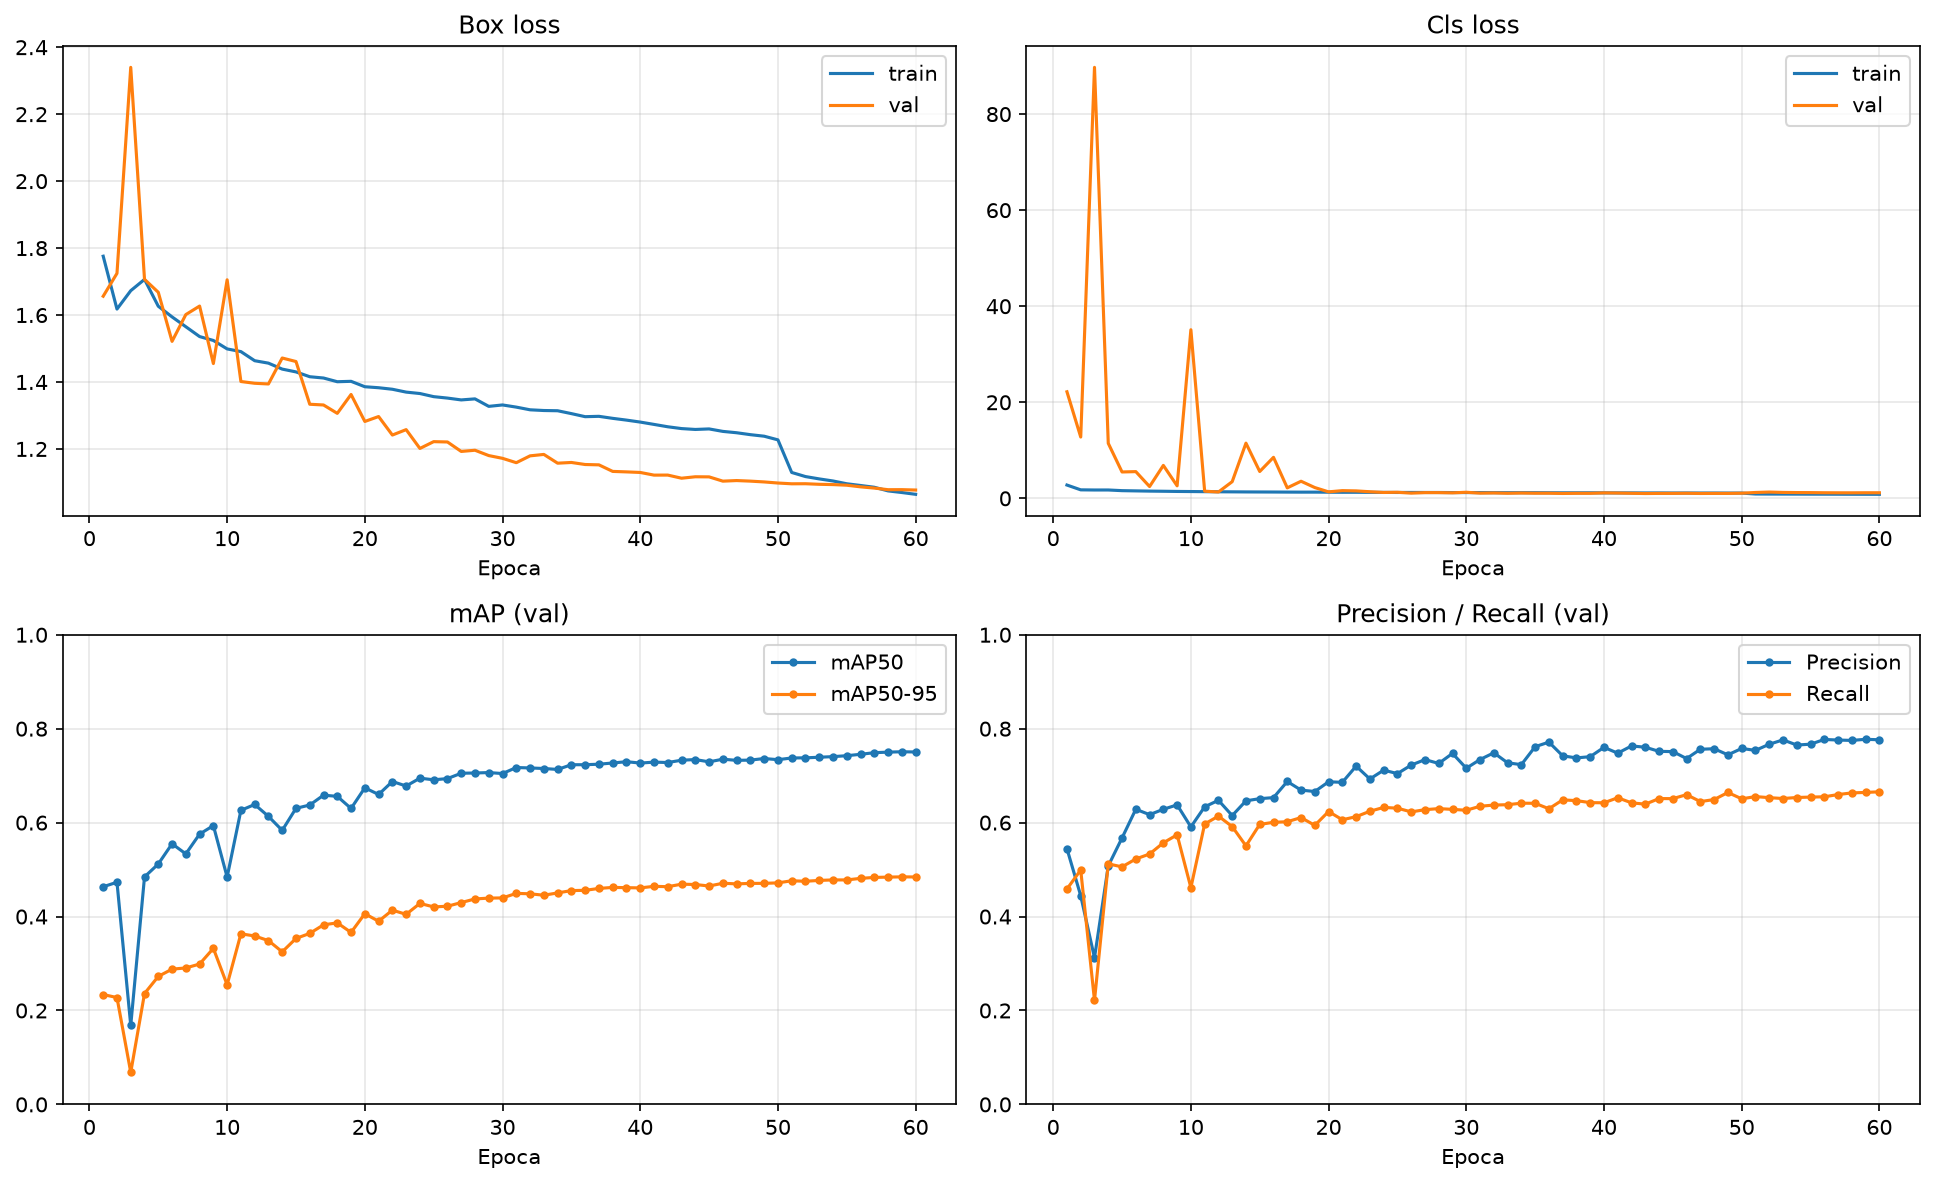

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Box loss
axes[0, 0].plot(yolo_hist["epoch"], yolo_hist["train/box_loss"], label="train")
axes[0, 0].plot(yolo_hist["epoch"], yolo_hist["val/box_loss"], label="val")
axes[0, 0].set_title("Box loss")
axes[0, 0].set_xlabel("Epoca")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Cls loss
axes[0, 1].plot(yolo_hist["epoch"], yolo_hist["train/cls_loss"], label="train")
axes[0, 1].plot(yolo_hist["epoch"], yolo_hist["val/cls_loss"], label="val")
axes[0, 1].set_title("Cls loss")
axes[0, 1].set_xlabel("Epoca")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# mAP
axes[1, 0].plot(yolo_hist["epoch"], yolo_hist["metrics/mAP50(B)"], marker=".", label="mAP50")
axes[1, 0].plot(yolo_hist["epoch"], yolo_hist["metrics/mAP50-95(B)"], marker=".", label="mAP50-95")
axes[1, 0].set_title("mAP (val)")
axes[1, 0].set_xlabel("Epoca")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Precision / Recall
axes[1, 1].plot(yolo_hist["epoch"], yolo_hist["metrics/precision(B)"], marker=".", label="Precision")
axes[1, 1].plot(yolo_hist["epoch"], yolo_hist["metrics/recall(B)"], marker=".", label="Recall")
axes[1, 1].set_title("Precision / Recall (val)")
axes[1, 1].set_xlabel("Epoca")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(YOLO_FIGURES_DIR / "yolo_curvas.png", dpi=150)
plt.show()


### 15.5 Visualizacion de predicciones

Se muestran detecciones del modelo sobre imagenes del split de test: cada defecto se acota con su bounding box, clase y confianza.


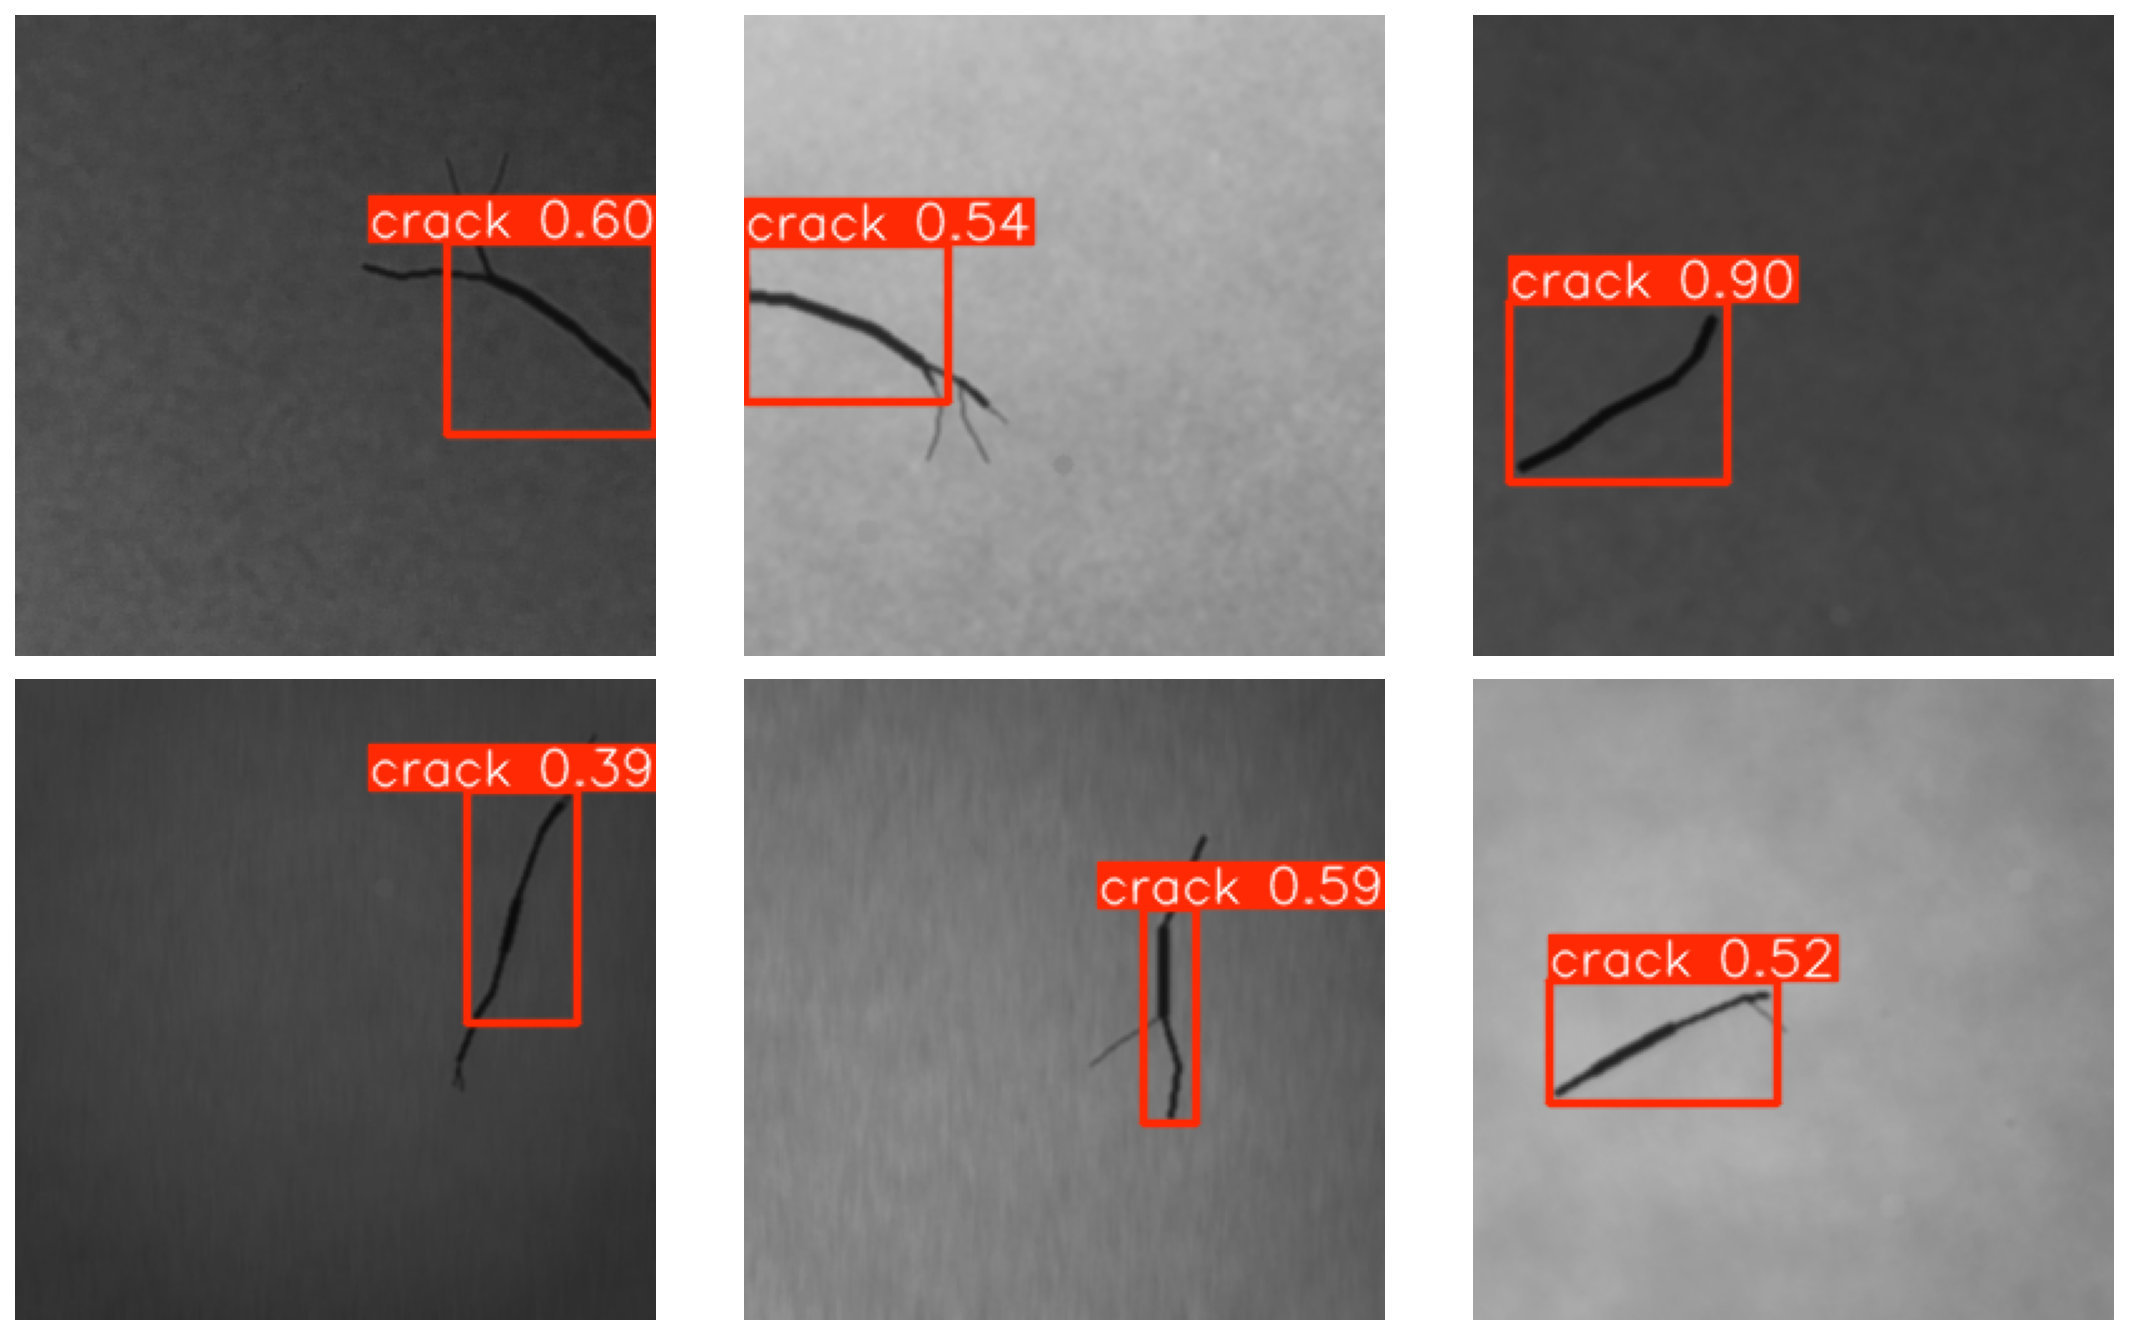

In [2]:
import glob as globlib

# Tomar algunas imagenes de test y predecir.
yolo_test_imgs = sorted(globlib.glob(str(YOLO_DATA_DIR / "test" / "images" / "*.png")))[:6]

yolo_pred = yolo_model.predict(
    source=yolo_test_imgs,
    imgsz=YOLO_IMGSZ,
    device=YOLO_DEVICE,
    conf=0.35,
    save=False,
    verbose=False,
)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, res in zip(axes.ravel(), yolo_pred):
    ax.imshow(res.plot())   # imagen con las cajas dibujadas
    ax.axis("off")
plt.tight_layout()
plt.savefig(YOLO_FIGURES_DIR / "yolo_predicciones.png", dpi=150)
plt.show()


### Interpretacion de los resultados de deteccion

Estas metricas corresponden al detector YOLOv8n entrenado **en este notebook** (Seccion 15) sobre el dataset combinado de **3 fuentes** (sintetico + SteelDefectX + NEU-DET), evaluado una sola vez sobre el split de test.

Metricas globales sobre test:

| Metrica | Valor |
|---|---|
| mAP50 | 0.739 |
| mAP50-95 | 0.488 |
| Precision | 0.754 |
| Recall | 0.663 |

AP50 por clase:

| Clase | AP50 | AP50-95 |
|---|---|---|
| crack | 0.791 | 0.541 |
| hole | 0.846 | 0.645 |
| rust | 0.677 | 0.407 |
| scratch | 0.643 | 0.361 |

- **NEU-DET aporta cajas reales anotadas** (formato Pascal VOC) para las 4 clases del proyecto, complementando las cajas derivadas por heuristicas de las imagenes sinteticas y de SteelDefectX; el split de test incluye 177 imagenes reales de NEU-DET no vistas en entrenamiento.
- **Sobre el early stopping:** el entrenamiento configuro `patience=15` y se completaron las 60 epocas (1.151 h en la RTX 5060 Ti).
- **Comparacion con clasificacion:** la clasificacion de imagen entera (secciones 7-12) llega a F1 = 1.0 con transfer learning, mientras que la deteccion se queda en ~0.74 de mAP50. La diferencia es esperada: clasificar es mas facil que localizar.
- **Costo/beneficio:** YOLOv8n (~3.0M parametros) se exporta a ONNX (~12 MB) y corre en el navegador a 20-30 FPS, lo que habilita la demo web en tiempo real sin servidor.
- **Nota historica:** una corrida previa de 100 epocas sobre la version de 2 fuentes del dataset (`outputs/yolo/train-3`, sin NEU-DET) alcanzo mAP50 ~0.80 y fue el checkpoint desplegado en la web hasta esta version.

> El script equivalente por linea de comandos (reproducible sin abrir Jupyter) es `python src/train_yolo.py`, que usa exactamente los mismos hiperparametros y guarda los pesos en `outputs/yolo/train/weights/best.pt`. La exportacion a la demo web se hace con `python src/export_detector_onnx.py`.
